In [179]:
import os.path
import numpy as np
import matplotlib.pyplot as plt

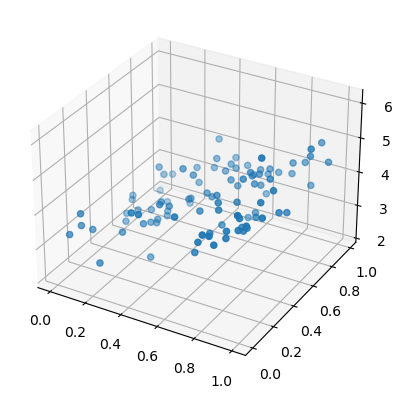

In [368]:
######################################
#
# FUNCTIONS YOU WILL NEED TO MODIFY:
#  - linreg_closed_form
#  - loss
#  - linreg_grad_desc
#  - random_fourier_features
#
######################################

def linreg_model_sample(Theta,model_X):
	if model_X.shape[1]==1:
		## get a bunch of evenly spaced X values in the same range as the passed in data
		sampled_X = numpy.linspace(model_X.min(axis=0),model_X.max(axis=0),100)
		## get the Y values for our sampled X values by taking the dot-product with the model
		## Note: we're appending a column of all ones so we can do this with a single matrix-vector multiply
		sampled_Y = numpy.hstack([numpy.ones((sampled_X.shape[0],1)),sampled_X]).dot(Theta)
		return sampled_X, sampled_Y
	elif model_X.shape[1]==2:
		## Unfortunately, plotting surfaces is a bit more complicated, first we need
		## a set of points that covers the area we want to plot. numpy.meshgrid is a helper function
		## that will create two NxN arrays that vary over both the X and Y range given.
		sampled_X, sampled_Y = numpy.meshgrid(model_X[:,0],model_X[:,1])
		## We can't just do a simple matrix multiply here, because plot_surface(...) is going to expect NxN arrays like
		## those generated by numpy.meshgrid(...). So here we're explicitly pulling out the components of Theta as
		## scalars and multiplying them across each element in the X and Y arrays to get the value for Z
		sampled_Z = sampled_X*Theta[1]+sampled_Y*Theta[2]+Theta[0]
		return sampled_X, sampled_Y, sampled_Z

def plot_helper(data_X, data_Y, model_X=None, model_Y=None, model_Z=None):
	import matplotlib.pyplot
	## 2D plotting
	## data_X.shape[1] is the number of columns in data_X, just as data_X.shape[0] is the number of rows
	if data_X.shape[1]==1: 
		fig1 = matplotlib.pyplot.figure() ## creates a new figure object that we can plot into
		fig1.gca().scatter(data_X,data_Y) ## creates a scatterplot with the given set of X and Y points
		## If we were given a model, we need to plot that
		if not(model_X is None) and not(model_Y is None):
			## Plot the data from the model
			## Note: we're using plot(...) instead of scatter(...) because we want a smooth curve
			fig1.gca().plot(model_X,model_Y,color='r')
		## The graph won't actually be displayed until we .show(...) it. You can swap this with savefig(...) if you
		## instead want to save an image of the graph instead of displaying it. You can also use the interface to save an
		## image after displaying it
		matplotlib.pyplot.show() #fig1.show()
	## 3D plotting
	elif data_X.shape[1]==2:
		## This import statement 'registers' the ability to do 3D projections/plotting with matplotlib
		from mpl_toolkits.mplot3d import Axes3D
		fig1 = matplotlib.pyplot.figure()
		## The format for 3D scatter is similar to 2D; just add the third dimension to the argument list
		fig1a = fig1.add_subplot(projection='3d')
		fig1a.scatter(data_X[:,0], data_X[:,1],data_Y)
		## Older versions of matplotlib allowed keyword arguments in the call to gca(), so the above 
		## two lines could be done in one. If you are using an older version of matplotlib that 
		## fails on the above lines, try line commented below, and the commented line inside the 
		## following if block
		# fig1.gca(projection='3d').scatter(data_X[:,0],data_X[:,1],data_Y)
		if not(model_X is None) and not(model_Y is None) and not(model_Z is None):
			## Now, with our X, Y, and Z arrays (all NxN), we can use plot_surface(...) to create a nice 3D surface
			fig1a.plot_surface(model_X, model_Y, model_Z,linewidth=0.0,color=(1.0,0.2,0.2,0.75))
			## See note in comment above
			# fig1.gca(projection='3d').plot_surface(model_X, model_Y, model_Z,linewidth=0.0,color=(1.0,0.2,0.2,0.75))
		matplotlib.pyplot.show() #fig1.show()
	else:
		## Matplotlib does not yet have the capability to plot in 4D
		print('Data is not in 2 or 3 dimensions, cowardly refusing to plot! (data_X.shape == {})'.format(data_X.shape))

## Data loading utility function
## i changed this line directory='data' to  directory=''
def load_data(fname,directory=''):
	data = numpy.loadtxt(os.path.join(directory,fname),delimiter=',')
	rows,cols = data.shape
	X_dim = cols-1
	Y_dim = 1
	return data[:,:-1].reshape(-1,X_dim), data[:,-1].reshape(-1,Y_dim)

def vis_linreg_model(train_X, train_Y, Theta):
    
        if Theta.ndim == 1:
            Theta = Theta[:, np.newaxis]  # Convert to column vector if it's a flat array

        if train_X.shape[1] == 1 or train_X.shape[1] == 2:
            # Ensure that train_X includes the bias term
            if train_X.shape[1] == Theta.shape[0] - 1:
                train_X = np.hstack([train_X, np.ones((train_X.shape[0], 1))])
        
        # Generate model predictions
            sampled_data = linreg_model_sample(Theta, train_X)
        
        # Visualization handling for 2D or 3D data
            if len(sampled_data) == 2:
                model_X, model_Y = sampled_data
                plot_helper(train_X, train_Y, model_X, model_Y)
            elif len(sampled_data) == 3:
                model_X, model_Y, model_Z = sampled_data
                plot_helper(train_X, train_Y, model_X, model_Y, model_Z)
            else:
                print("Unexpected number of outputs from linreg_model_sample.")
        else:
            print("Model only supports 2D or 3D data for visualization.")

            #NOTE: this won't work directly with 3D data. Write your own function, or modify this one
            #to generate plots for 2D-noisy-lin.txt or other 3D data.
    

###################
# YOUR CODE BELOW #
###################
def linreg_closed_form(train_X, train_Y):
    X = numpy.hstack([numpy.ones((train_X.shape[0], 1)), train_X])  # Adding a column of ones for the intercept term
    Y = train_Y
    Theta = numpy.linalg.inv(X.T @ X) @ X.T @ Y

    
    #Theta = None # TODO: compute the closed form solution here. Note: using numpy.linalg.lstsq(...) is *not* the correct answer
    
    return Theta
    '''
    Computes the optimal parameters for the given training data in closed form
    
    
    Args:
        train_X (N-by-D numpy array): Training data features as a matrix of row vectors (train_X[i][j] is the jth component of the ith example)
        train_Y (length N numpy array): The training data target as a length N vector
    
    
    Returns:
        A length D+1 numpy array with the optimal parameters	
    '''

###################
# YOUR CODE BELOW #
###################
def loss(Theta, train_X, train_Y):
	

    los = np.sum(np.dot(train_X,Theta) - train_Y ** 2) / (2 * len(train_Y)) # TODO: compute the loss here.
    
    return los

###################
# YOUR CODE BELOW #
###################
def linreg_grad_desc(initial_Theta, train_X, train_Y, alpha=0.05, num_iters=1000, print_iters=True):

        cur_Theta = initial_Theta

        step_history = list()
        for k in range(1,num_iters+1):
            predictions = np.dot(train_X, cur_Theta)
            residuals = predictions - train_Y
            gradient = np.dot(train_X.T, residuals) / len(train_Y)
            
            cur_loss = loss(cur_Theta, train_X, train_Y)
            step_history.append((cur_Theta, cur_loss))
            if print_iters:
                print("Iteration: {} , Loss: {} , Theta: {}".format(k,cur_loss,cur_Theta))
            #TODO: Add update equation here
            
        return step_history

def apply_RFF_transform(X,Omega,B):
    '''
    Transforms features into a Fourier basis with given samples

        Given a set of random inner products and translations, transform X into the Fourier basis, Phi(X)
            phi_k(x) = cos(<x,omega_k> + b_k)                           #scalar form
            Phi(x) = sqrt(1/D)*[phi_1(x), phi_2(x), ..., phi_NFF(x)].T  #vector form
            Phi(X) = [Phi(x_1), Phi(x_2), ..., Phi(x_N)].T              #matrix form


    Args:
        X (N-by-D numpy array): matrix of row-vector features (may also be a single row-vector)
        Omega (D-by-NFF numpy array): matrix of row-vector inner products
        B (NFF length numpy array): vector of translations



    Returns:
        A N-by-NFF numpy array matrix of transformed points, Phi(X)

    '''
    Phi = np.sqrt(1.0 / Omega.shape[1]) * np.cos(np.dot(X, Omega) + B)
    Phi = np.hstack([Phi, np.ones((Phi.shape[0], 1))])
    return Phi
	#return numpy.sqrt(1.0/Omega.shape[1])*numpy.cos(X.dot(Omega)+B)

##################
# YOUR CODE HERE #
##################
def random_fourier_features(train_X, train_Y, num_fourier_features=100, alpha=0.05, num_iters=500, print_iters=False):
    '''
    Creates a random set of Fourier basis functions and fits a linear model in this space.

        Randomly sample num_fourier_features's non-linear transformations of the form:

            phi_k(x) = cos(<x,omega_k> + b_k)
            Phi(x) = sqrt(1/D)*[phi_1(x), phi_2(x), ..., phi_NFF(x)]

        where omega_k and b_k are sampled according to (Rahimi and Recht, 20018). 


    Args:
        train_X (N-by-D numpy array): Training data features as a matrix of row vectors (train_X[i][j] is the jth component of the ith example)
        train_Y (length N numpy array): The training data target as a length N vector
        num_fourier_features (int): the number of random features to generate


    Returns:
        Theta (numpy array of length num_fourier_features+1): the weights for the *transformed* model
        Omega (D-by-num_fourier_features numpy array): the inner product term of the transformation
        B (numpy array of length num_fourier_features): the translation term of the transformation
    '''
    # You will find the following functions useful for sampling:
    # 	numpy.random.multivariate_normal() for normal random variables
    #	numpy.random.random() for Uniform random variables
    Omega = np.random.normal(loc=0.0, scale=1.0, size=(D, num_fourier_features))# TODO: sample inner-products
    B = np.random.uniform(low=0, high=2*np.pi, size=(num_fourier_features,))# TODO: sample translations
    Phi = apply_RFF_transform(train_X,Omega,B)
    
    # here's an example of using numpy.random.random()
    # to generate a vector of length = (num_fourier_features), between -0.1 and 0.1
    initial_Theta = (numpy.random.random(size=(num_fourier_features+1,1))-0.5)*0.2
    step_history = linreg_grad_desc(initial_Theta,Phi,train_Y,alpha=alpha,num_iters=num_iters,print_iters=print_iters)
    return step_history[-1][0], Omega, B

def rff_model_sample(Theta,Omega,B,model_X):
	sampled_X = numpy.linspace(model_X.min(axis=0),model_X.max(axis=0),100)
	Phi = apply_RFF_transform(sampled_X,Omega,B)
	sampled_Y = Phi.dot(Theta)
	return sampled_X, sampled_Y

def vis_rff_model(train_X, train_Y, Theta, Omega, B):
	sample_X, sample_Y = rff_model_sample(Theta,Omega,B, train_X)
	plot_helper(train_X, train_Y, sample_X, sample_Y)

if __name__ == '__main__':
	data_X, data_Y = load_data('2D-noisy-lin.txt')
	plot_helper(data_X, data_Y)

In [369]:
data_X, data_Y = load_data('2D-noisy-lin.txt')
theta = linreg_closed_form(data_X, data_Y)

In [370]:
data_X2, data_Y2 = load_data('1D-no-noise-lin.txt')
theta2 = linreg_closed_form(data_X2, data_Y2)

In [371]:
theta2

array([[0. ],
       [0.5]])

In [372]:
theta

array([[ 2.93987438],
       [ 2.04156149],
       [-0.43683838]])

In [373]:
#Linear regression
A = np.hstack([data_X, np.ones((data_X.shape[0], 1))])
Theta_best, residuals, rank, s = np.linalg.lstsq(A, data_Y, rcond=None)

print("Best fit parameters:", Theta_best)

Best fit parameters: [[ 2.04156149]
 [-0.43683838]
 [ 2.93987438]]


In [374]:
#Linear Regression
A = np.hstack([data_X2, np.ones((data_X2.shape[0], 1))])
Theta_best, residuals, rank, s = np.linalg.lstsq(A, data_Y2, rcond=None)

print("Best fit parameters:", Theta_best)

Best fit parameters: [[ 5.00000000e-01]
 [-5.40925736e-16]]


In [381]:
#Gradient Descent
final_Theta = linreg_grad_desc(initial_Theta, data_X, data_Y)[-1][0]
vis_linreg_model(data_X, data_Y, final_Theta)

Iteration: 1 , Loss: -5.8683245422692805 , Theta: [[4.46715737]
 [1.97034174]]
Iteration: 2 , Loss: -5.8683245422692805 , Theta: [[4.46715737]
 [1.97034174]]
Iteration: 3 , Loss: -5.8683245422692805 , Theta: [[4.46715737]
 [1.97034174]]
Iteration: 4 , Loss: -5.8683245422692805 , Theta: [[4.46715737]
 [1.97034174]]
Iteration: 5 , Loss: -5.8683245422692805 , Theta: [[4.46715737]
 [1.97034174]]
Iteration: 6 , Loss: -5.8683245422692805 , Theta: [[4.46715737]
 [1.97034174]]
Iteration: 7 , Loss: -5.8683245422692805 , Theta: [[4.46715737]
 [1.97034174]]
Iteration: 8 , Loss: -5.8683245422692805 , Theta: [[4.46715737]
 [1.97034174]]
Iteration: 9 , Loss: -5.8683245422692805 , Theta: [[4.46715737]
 [1.97034174]]
Iteration: 10 , Loss: -5.8683245422692805 , Theta: [[4.46715737]
 [1.97034174]]
Iteration: 11 , Loss: -5.8683245422692805 , Theta: [[4.46715737]
 [1.97034174]]
Iteration: 12 , Loss: -5.8683245422692805 , Theta: [[4.46715737]
 [1.97034174]]
Iteration: 13 , Loss: -5.8683245422692805 , Theta

IndexError: index 2 is out of bounds for axis 0 with size 2

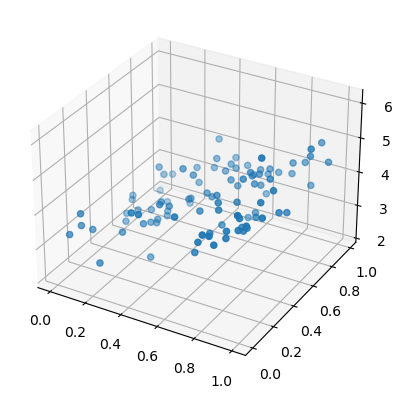

In [382]:
plot_helper(data_X, data_Y, final_Theta)

In [384]:
#Gradient Descent
if data_X2.shape[1] == theta2.shape[0] - 1:
    data_X2_bias = np.hstack([data_X2, np.ones((data_X2.shape[0], 1))])
else:
    data_X2_bias = data_X2
    
final_Theta = linreg_grad_desc(initial_Theta, data_X2_bias, data_Y2)[-1][0]
vis_linreg_model(data_X2_bias, data_Y2, final_Theta)


Iteration: 1 , Loss: 7.473774949078646 , Theta: [[4.46715737]
 [1.97034174]]
Iteration: 2 , Loss: 7.473774949078646 , Theta: [[4.46715737]
 [1.97034174]]
Iteration: 3 , Loss: 7.473774949078646 , Theta: [[4.46715737]
 [1.97034174]]
Iteration: 4 , Loss: 7.473774949078646 , Theta: [[4.46715737]
 [1.97034174]]
Iteration: 5 , Loss: 7.473774949078646 , Theta: [[4.46715737]
 [1.97034174]]
Iteration: 6 , Loss: 7.473774949078646 , Theta: [[4.46715737]
 [1.97034174]]
Iteration: 7 , Loss: 7.473774949078646 , Theta: [[4.46715737]
 [1.97034174]]
Iteration: 8 , Loss: 7.473774949078646 , Theta: [[4.46715737]
 [1.97034174]]
Iteration: 9 , Loss: 7.473774949078646 , Theta: [[4.46715737]
 [1.97034174]]
Iteration: 10 , Loss: 7.473774949078646 , Theta: [[4.46715737]
 [1.97034174]]
Iteration: 11 , Loss: 7.473774949078646 , Theta: [[4.46715737]
 [1.97034174]]
Iteration: 12 , Loss: 7.473774949078646 , Theta: [[4.46715737]
 [1.97034174]]
Iteration: 13 , Loss: 7.473774949078646 , Theta: [[4.46715737]
 [1.970341

IndexError: index 2 is out of bounds for axis 0 with size 2

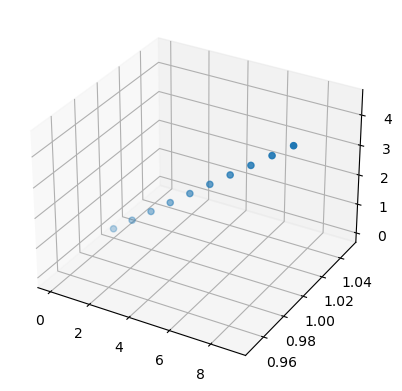

In [385]:
plot_helper(data_X2_bias, data_Y2, final_Theta)

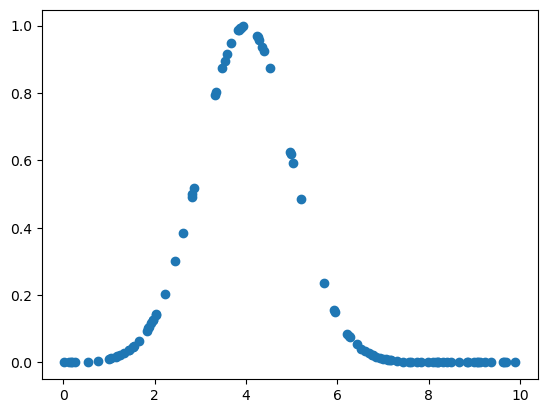

ZeroDivisionError: float division by zero

In [399]:
if __name__ == '__main__':
    datasets = ['1D-exp-samp.txt', '1D-exp-uni.txt', '1D-quad-uni.txt', '1D-quad-uni-noise.txt']
    ks = [0,5, 10, 50, 100, 200, 300, 400, 500, 600, 700, 800] 


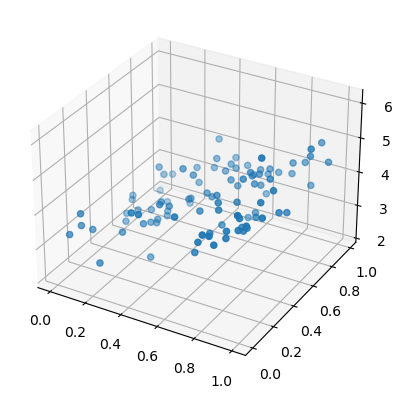

In [302]:
num_features = 100
D = data_X.shape[1]
Theta = np.random.randn(num_features + 1, 1)
Omega = np.random.normal(0, 1, (D, num_features))
B = np.random.uniform(0, 2 * np.pi, num_features)
vis_rff_model(data_X, data_Y, Theta, Omega, B)

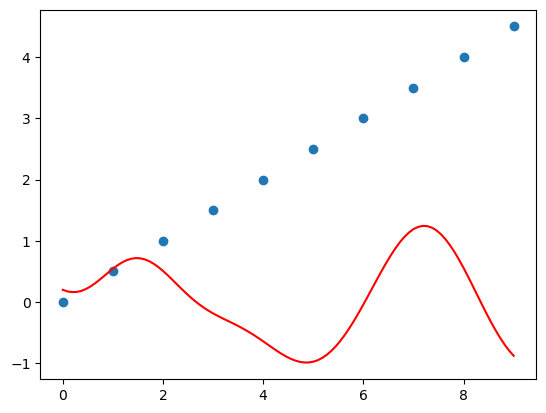

In [303]:
num_features = 100
D = data_X2.shape[1]
Theta = np.random.randn(num_features + 1, 1)
Omega = np.random.normal(0, 1, (D, num_features))
B = np.random.uniform(0, 2 * np.pi, num_features)
vis_rff_model(data_X2, data_Y2, Theta, Omega, B)